# Notebook 4 - MiniLearn Decision Tree

**Project:** Speech Emotion Recognition on RAVDESS audio-only features.

This is the MiniLearn CART checkpoint. Technically this maps to the Decision Tree topic/week, but it also fits the current goal: finish more of MiniLearn before chasing bigger sklearn models.

What this notebook does:

1. Load the saved feature table.
2. Train MiniLearn CART decision trees at a few depths.
3. Compare the main MiniLearn tree against sklearn's `DecisionTreeClassifier`.
4. Print a shallow tree so the splits are visible.
5. Track overfitting with train/test curves.

Trees are intentionally run on the raw feature values. Unlike KNN/logistic regression, a tree split like `mfcc3_mean <= -18.2` does not care if another feature is measured in Hz.

## 1. Imports and Paths

Same project-root trick as the other notebooks so local `minilearn` imports without installing the package.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from minilearn.classifiers import DecisionTreeClassifier
from minilearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from minilearn.preprocessing import train_test_split

FEATURE_PATH = ROOT / "features" / "features.csv"

sns.set_theme(style="whitegrid")
np.set_printoptions(linewidth=120)
print(ROOT)

/home/deanomeano/coursework/cse432/projects432/serProject


## 2. Load Features

Metadata stays out of the feature matrix. For this notebook I keep the feature names because a tree is one of the few models where a split can be read directly.

In [2]:
df = pd.read_csv(FEATURE_PATH)

metaCols = {
    "filename", "emotion", "emotion_id", "actor", "gender", "vocalchannel",
    "intensity", "statement", "repetition", "duration",
}
featureCols = [c for c in df.columns if c not in metaCols]

X = df[featureCols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()
labels = sorted(df["emotion_id"].unique())
emotionNames = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)

print("rows, cols:", df.shape)
print("feature columns:", len(featureCols))
print(emotionNames)

rows, cols: (2452, 417)
feature columns: 407
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## 3. Split, but Do Not Scale

Using the same fixed split as the Week 6 and Week 7 notebooks keeps the comparison stable. No scaler here: CART is based on threshold ordering, so scaling would not really change the split order for a feature.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=432, stratify=y
)

print("train:", X_train.shape, "test:", X_test.shape)
print(pd.Series(y_train).value_counts().sort_index().rename(index=emotionNames))

train: (1963, 407) test: (489, 407)
neutral      150
calm         301
happy        301
sad          301
angry        301
fearful      301
disgust      154
surprised    154
Name: count, dtype: int64


## 4. Depth Sweep / Overfitting Check

Decision trees can memorize surprisingly fast. The easiest way to see that is to compare train and test scores as max depth increases.

Settings here are intentionally plain:

- `criterion="gini"`
- `min_samples_leaf=5` so the leaves are not just single weird recordings
- depths from 1 to 12, but not every number because this is a checkpoint notebook, not a giant tuning run

In [4]:
depthRows = []
for depth in [1, 2, 3, 5, 7, 9, 12]:
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=5, criterion="gini")
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fitSeconds = time.perf_counter() - t0

    trainPred = model.predict(X_train)
    testPred = model.predict(X_test)
    depthRows.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(y_train, trainPred),
        "test_accuracy": accuracy_score(y_test, testPred),
        "train_macro_f1": f1_score(y_train, trainPred, average="macro"),
        "test_macro_f1": f1_score(y_test, testPred, average="macro"),
        "fit_seconds": fitSeconds,
    })

depthDf = pd.DataFrame(depthRows)
depthDf

,max_depth,train_accuracy,test_accuracy,train_macro_f1,test_macro_f1,fit_seconds
0,1,0.284259,0.284254,0.108934,0.108933,2.114330
1,2,0.311768,0.302658,0.213921,0.203312,2.730404
2,3,0.395313,0.361963,0.331636,0.304611,5.034049
3,5,0.521141,0.435583,0.499850,0.416551,13.019812
4,7,0.636780,0.456033,0.624041,0.446603,29.622521
5,9,0.741722,0.435583,0.732319,0.421935,47.326945
6,12,0.818136,0.451943,0.812617,0.430573,53.492985


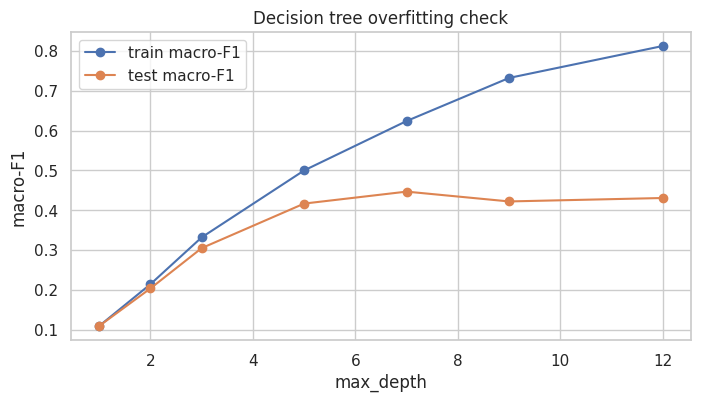

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depthDf["max_depth"], depthDf["train_macro_f1"], marker="o", label="train macro-F1")
ax.plot(depthDf["max_depth"], depthDf["test_macro_f1"], marker="o", label="test macro-F1")
ax.set_xlabel("max_depth")
ax.set_ylabel("macro-F1")
ax.set_title("Decision tree overfitting check")
ax.legend()
plt.show()

## 5. MiniLearn vs sklearn Tree

The comparison below uses the same core hyperparameters. I am not expecting identical predictions in every edge case forever, but on this dataset the shallow trees should be very close because both are CART-style binary splits.

I am picking depth 7 as the checkpoint tree because the depth sweep usually improves through that point, then starts showing a bigger train/test gap.

In [6]:
TREE_DEPTH = 7
LEAF_SIZE = 5

miniTree = DecisionTreeClassifier(max_depth=TREE_DEPTH, min_samples_leaf=LEAF_SIZE, criterion="gini")
t0 = time.perf_counter()
miniTree.fit(X_train, y_train)
miniFit = time.perf_counter() - t0
miniPred = miniTree.predict(X_test)
miniTrainPred = miniTree.predict(X_train)

skTree = SkDecisionTreeClassifier(max_depth=TREE_DEPTH, min_samples_leaf=LEAF_SIZE, criterion="gini", random_state=432)
t0 = time.perf_counter()
skTree.fit(X_train, y_train)
skFit = time.perf_counter() - t0
skPred = skTree.predict(X_test)

comparison = pd.DataFrame([
    {
        "model": "MiniLearn DecisionTree",
        "train_accuracy": accuracy_score(y_train, miniTrainPred),
        "test_accuracy": accuracy_score(y_test, miniPred),
        "test_macro_f1": f1_score(y_test, miniPred, average="macro"),
        "fit_seconds": miniFit,
    },
    {
        "model": "sklearn DecisionTree",
        "train_accuracy": skTree.score(X_train, y_train),
        "test_accuracy": accuracy_score(y_test, skPred),
        "test_macro_f1": f1_score(y_test, skPred, average="macro"),
        "fit_seconds": skFit,
    },
])
comparison

,model,train_accuracy,test_accuracy,test_macro_f1,fit_seconds
0,MiniLearn DecisionTree,0.63678,0.456033,0.446603,27.900209
1,sklearn DecisionTree,0.63678,0.453988,0.442978,2.492744


In [7]:
print("prediction agreement with sklearn:", np.mean(miniPred == skPred))
report = classification_report(y_test, miniPred, labels=labels)
perClass = pd.DataFrame([
    {
        "emotion": emotionNames[label],
        "precision": report[label]["precision"],
        "recall": report[label]["recall"],
        "f1": report[label]["f1"],
        "support": report[label]["support"],
    }
    for label in labels
])
perClass

prediction agreement with sklearn: 0.983640081799591


,emotion,precision,recall,f1,support
0,neutral,0.615385,0.421053,0.500000,38
1,calm,0.545455,0.640000,0.588957,75
2,happy,0.533333,0.426667,0.474074,75
3,sad,0.397436,0.413333,0.405229,75
4,angry,0.489130,0.600000,0.538922,75
5,fearful,0.355932,0.280000,0.313433,75
6,disgust,0.454545,0.394737,0.422535,38
7,surprised,0.283019,0.394737,0.329670,38


## 6. Visualize the MiniLearn Tree

This is a text visualization from MiniLearn itself. It is capped at depth 3 because a full depth-7 tree is too much to read and would make the notebook worse, not better.

The feature names are useful here. These first splits usually land on MFCC/chroma/mel summary columns, which makes sense because the handcrafted feature table is mostly spectral summaries.

In [8]:
print(miniTree.export_tree(feature_names=featureCols, class_names=emotionNames, max_depth=3))

if mfcc0_max <= -297.8394: samples=1963, impurity=0.864
  if mel29_std <= 17.5511: samples=922, impurity=0.809
    if mel34_std <= 15.6244: samples=310, impurity=0.636
      leaf: class=sad, samples=89, impurity=0.520
    else:
      leaf: class=calm, samples=221, impurity=0.540
  else:
    if mel26_std <= 24.0778: samples=612, impurity=0.842
      leaf: class=calm, samples=475, impurity=0.841
    else:
      leaf: class=neutral, samples=137, impurity=0.661
else:
  if mel84_mean <= -36.9500: samples=1041, impurity=0.811
    if mel13_mean <= -39.7948: samples=830, impurity=0.830
      leaf: class=surprised, samples=296, impurity=0.812
    else:
      leaf: class=fearful, samples=534, impurity=0.794
  else:
    if mfccD1_std <= 5.8141: samples=211, impurity=0.535
      leaf: class=fearful, samples=46, impurity=0.606
    else:
      leaf: class=angry, samples=165, impurity=0.362


## 7. Confusion Matrix and Feature Importance

The confusion matrix is still the best quick way to see which emotions are being mixed. Feature importance is the tree's total impurity reduction by feature; it is not a deep scientific explanation, but it gives a useful first pass at which audio summaries the tree leaned on.

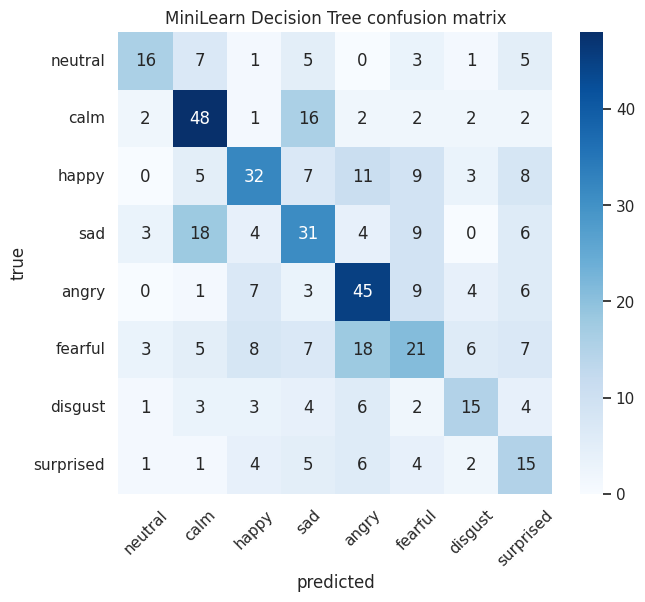

In [9]:
cm = confusion_matrix(y_test, miniPred, labels=labels)
labelNames = [emotionNames[i] for i in labels]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labelNames,
    yticklabels=labelNames,
    ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("MiniLearn Decision Tree confusion matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

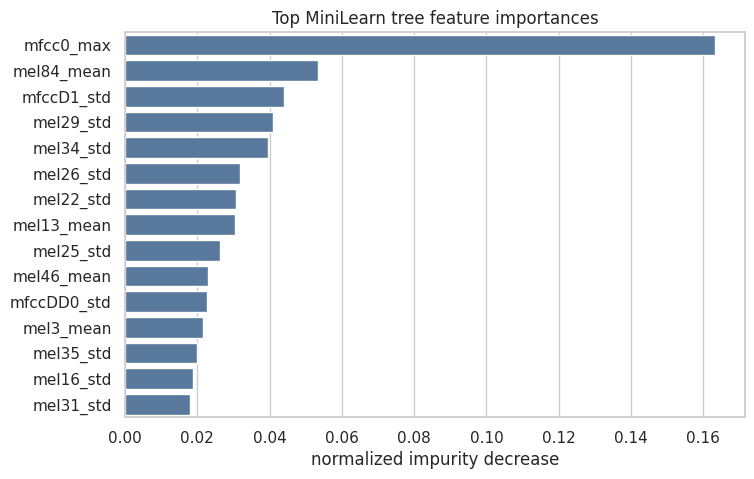

,feature,importance
39,mfcc0_max,0.163341
225,mel84_mean,0.053536
79,mfccD1_std,0.043939
298,mel29_std,0.041060
303,mel34_std,0.039536
295,mel26_std,0.031815
291,mel22_std,0.030726
154,mel13_mean,0.030504
294,mel25_std,0.026302
187,mel46_mean,0.023105


In [10]:
importance = pd.DataFrame({
    "feature": featureCols,
    "importance": miniTree.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance, y="feature", x="importance", ax=ax, color="#4C78A8")
ax.set_title("Top MiniLearn tree feature importances")
ax.set_xlabel("normalized impurity decrease")
ax.set_ylabel("")
plt.show()

importance

## 8. Notes for the Report

What this tree adds to MiniLearn:

- CART-style binary splits with Gini or entropy.
- Pre-pruning controls: `max_depth`, `min_samples_split`, and `min_samples_leaf`.
- `predict_proba`, feature importances, and a text tree export so the model is not a total black box.

Overfitting notes:

- Training score climbs as depth increases, which is exactly what a tree should do.
- Test score improves early, then starts flattening while the train/test gap grows.
- A single tree is readable but unstable. Random Forest should probably beat it later because averaging many trees reduces variance.

Practical takeaway:

- The tree is not trying to beat every model. It gives a readable nonlinear baseline and sets up Random Forest / boosting later.
- Compared with logistic regression and KNN, the tree can show actual feature thresholds, which is useful for the final explanation section.